# 🚀 Senior-Level Customer Churn Prediction (Advanced End-to-End)
Includes EDA, Outlier Handling, Multicollinearity, Class Imbalance, Multi-model Comparison, and Model Saving

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import joblib
import shap



In [22]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [23]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [24]:
numerical_features_list = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in df.columns:
    if col not in numerical_features_list:
        print(col, df[col].unique())
        print("-"*50)

print(df.isnull().sum())

customerID <StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str
--------------------------------------------------
gender <StringArray>
['Female', 'Male']
Length: 2, dtype: str
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner <StringArray>
['Yes', 'No']
Length: 2, dtype: str
--------------------------------------------------
Dependents <StringArray>
['No', 'Yes']
Length: 2, dtype: str
--------------------------------------------------
PhoneService <StringArray>
['No', 'Yes']
Length: 2, dtype: str
--------------------------------------------------
MultipleLines <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
-------

In [25]:
df.drop('customerID', axis=1, inplace=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

/tmp/ipykernel_38669/3808859548.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['TotalCharges'].fillna(0, inplace=True)


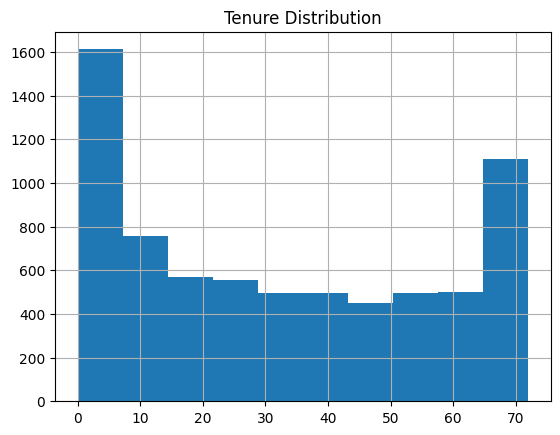

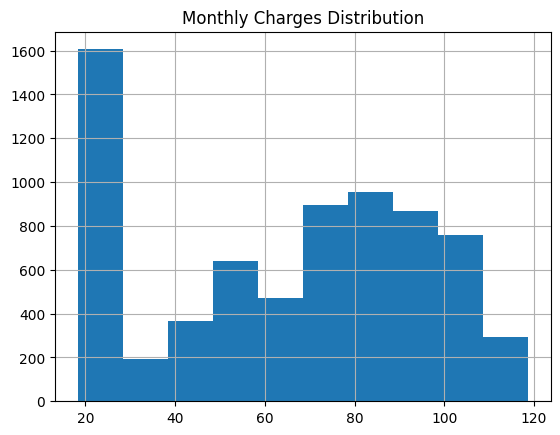

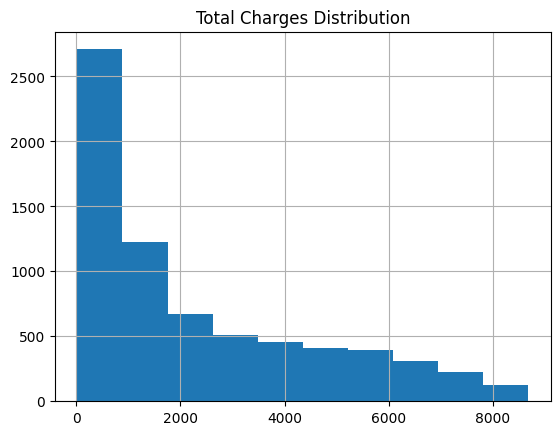

In [26]:
df['tenure'].hist()
plt.title('Tenure Distribution')
plt.show()

df['MonthlyCharges'].hist()
plt.title('Monthly Charges Distribution')
plt.show()

df['TotalCharges'].hist()
plt.title('Total Charges Distribution')
plt.show()

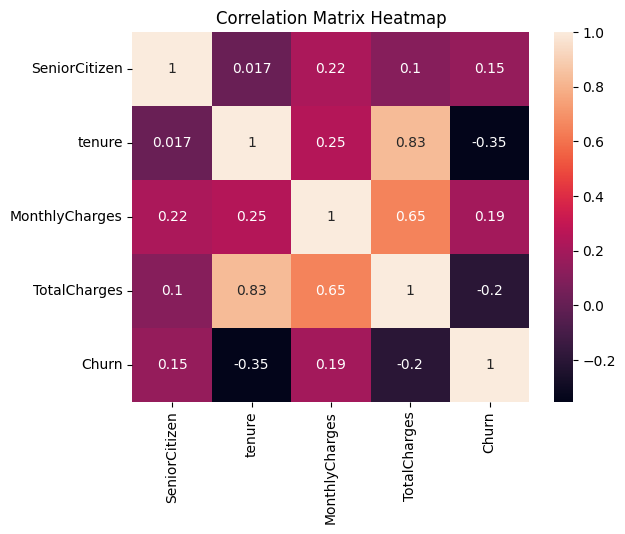

In [27]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [28]:
# Remove outliers using IQR
for col in ['tenure','MonthlyCharges','TotalCharges']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

In [29]:
print("Class Distribution:")
print(df['Churn'].value_counts(normalize=True))

Class Distribution:
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


In [30]:
categorical_cols = df.select_dtypes(include=['object','string']).columns
numeric_cols = df.select_dtypes(exclude=['object','string']).drop('Churn', axis=1).columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

In [31]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [32]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

In [33]:
results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = (pipe, acc)
    print(f"{name} Accuracy: {acc}")

Logistic Regression Accuracy: 0.8038379530916845
Random Forest Accuracy: 0.7882018479033405
XGBoost Accuracy: 0.7668798862828714


In [34]:
best_model_name = max(results, key=lambda x: results[x][1])
best_model, best_acc = results[best_model_name]

print("Best Model:", best_model_name)
print("Best Accuracy:", best_acc)

Best Model: Logistic Regression
Best Accuracy: 0.8038379530916845


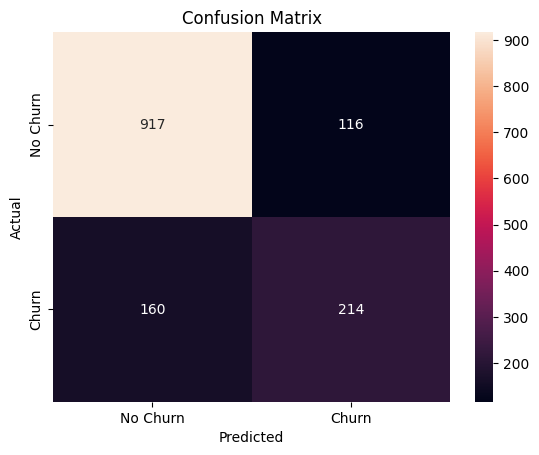

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [35]:
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(y_test, y_pred))

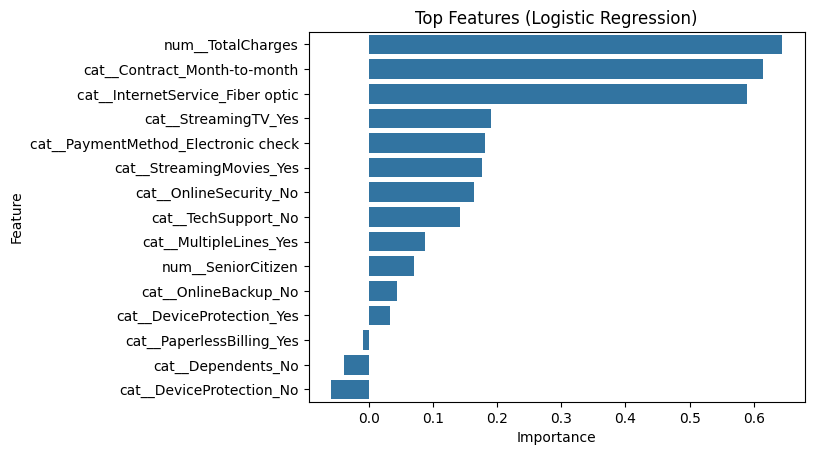

In [41]:
model = best_model.named_steps['model']

if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_
    feature_names = best_model.named_steps['prep'].get_feature_names_out()

    feat_df = pd.DataFrame({'Feature':feature_names,'Importance':importances})
    feat_df = feat_df.sort_values(by='Importance', ascending=False).head(15)

    sns.barplot(data=feat_df, x='Importance', y='Feature')
    plt.title('Top Feature Importances')
    plt.show()
elif hasattr(model, 'coef_'):
    feature_names = best_model.named_steps['prep'].get_feature_names_out()
    importance = model.coef_[0]

    import pandas as pd
    feat_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    }).sort_values(by='Importance', ascending=False).head(15)

    sns.barplot(data=feat_df, x='Importance', y='Feature')
    plt.title('Top Features (Logistic Regression)')
    plt.show()    

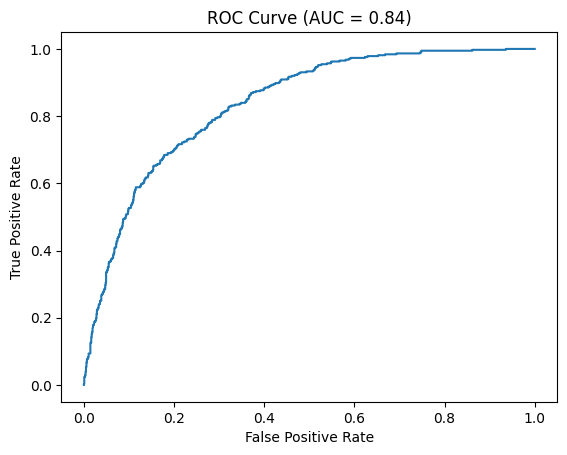

In [37]:
# ROC Curve
y_prob = best_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.title(f"ROC Curve (AUC = {roc_auc:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


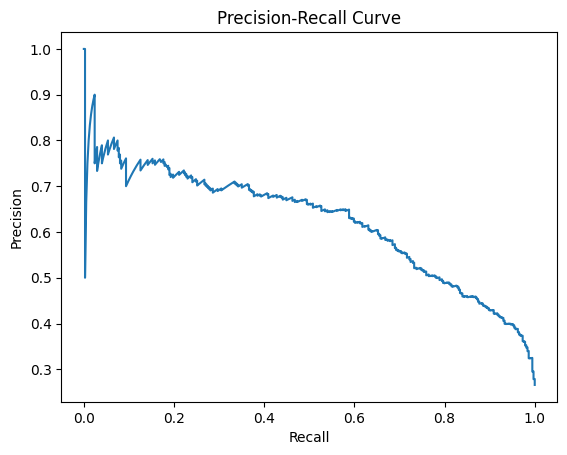

In [38]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

In [39]:
# Cross Validation
scores = cross_val_score(best_model, X, y, cv=5, scoring='accuracy')
print("Cross-validation scores:", scores)
print("Mean CV Accuracy:", scores.mean())

Cross-validation scores: [0.80170576 0.81236674 0.79231863 0.80796586 0.8029872 ]
Mean CV Accuracy: 0.8034688374829774


In [40]:
# SHAP Explainability
explainer = shap.Explainer(best_model.named_steps['model'])
X_sample = best_model.named_steps['prep'].transform(X_test)

shap_values = explainer(X_sample)

shap.summary_plot(shap_values, X_sample)

TypeError: The passed model is not callable and cannot be analyzed directly with the given masker! Model: LogisticRegression(max_iter=1000)

In [ ]:
joblib.dump(best_model, 'final_churn_model.pkl')

['final_churn_model.pkl']